In [30]:
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [31]:
def acess_factor(label):
    
    FF = pd.read_csv(f'../data/fatores_ff/ff_{label}.csv')
    FF["Date"] = pd.to_datetime(FF["Date"], format='%Y%m') + pd.offsets.MonthEnd(0)
    FF.set_index("Date", inplace=True)
    FF = FF[["Mkt-RF", "SMB", "HML", "RF"]] / 100

    return FF

In [32]:
def acess_data_etf(ticker_symbol, date_start, date_end):

    DATA_ETF = yf.download(
        tickers=ticker_symbol,
        start = pd.to_datetime(date_start) - pd.DateOffset(months=1),
        end = '2024-12-31',
        interval="1d",
        auto_adjust=False,
        progress=False
    )

    if "Adj Close" not in DATA_ETF.columns:
        DATA_ETF["Adj Close"] = DATA_ETF["Close"]

    DATA_ETF = (
        DATA_ETF
            .resample("ME").last()[['Adj Close']]
            .pct_change()
            .dropna()
    )

    DATA_ETF.columns = ['adj_close']

    return DATA_ETF

In [ ]:
def gera_grafico_ff(df, model):
    
    df['ff_excess_return'] = model.fittedvalues
    df['ff_total_return'] = df['ff_excess_return'] + df['RF']

    plt.figure(figsize=(12, 6))

    plt.plot(
        df.index,
        df['adj_close'],
        label='Retorno real',
        linewidth = 2.2
    )

    plt.plot(
        df.index,
        df['ff_total_return'],
        label='Retorno explicado (Fama-French)',
        linestyle='--',
        linewidth = 2,
        alpha = 0.85
    )

    plt.axhline(0, linestyle=':', linewidth=1)

    plt.title(
        'EWJ — Retorno mensal real vs explicado pelo modelo Fama-French',
        fontsize=14
    )
    plt.xlabel('Data')
    plt.ylabel('Retorno mensal')

    plt.grid(alpha=0.3)

    plt.legend()

    plt.tight_layout()
    plt.show()


In [37]:
def french_fama(ticker_symbol, label, date_start, date_end):
    FF = acess_factor(label)
    DATA_ETF = acess_data_etf(ticker_symbol, date_start, date_end)
    
    DATA = DATA_ETF.merge(FF, how='left', left_index=True, right_index=True)
    DATA['excess_return'] = DATA['adj_close'] - DATA['RF']

    Y = DATA['excess_return']
    X = DATA[['Mkt-RF', 'SMB', 'HML']]
    model = sm.OLS(Y, X).fit()

    r2 =  model.rsquared
    mse = model.mse_resid

    betas = model.params
    factor_means = DATA[['Mkt-RF', 'SMB', 'HML']].mean()
    rf_mean = DATA['RF'].mean()

    E_return = rf_mean + betas @ factor_means
    E_return_annual = (1 + E_return) ** 12 - 1

    gera_grafico_ff(DATA, model)

    return (E_return_annual * 100, r2 * 100, mse * 100, model)

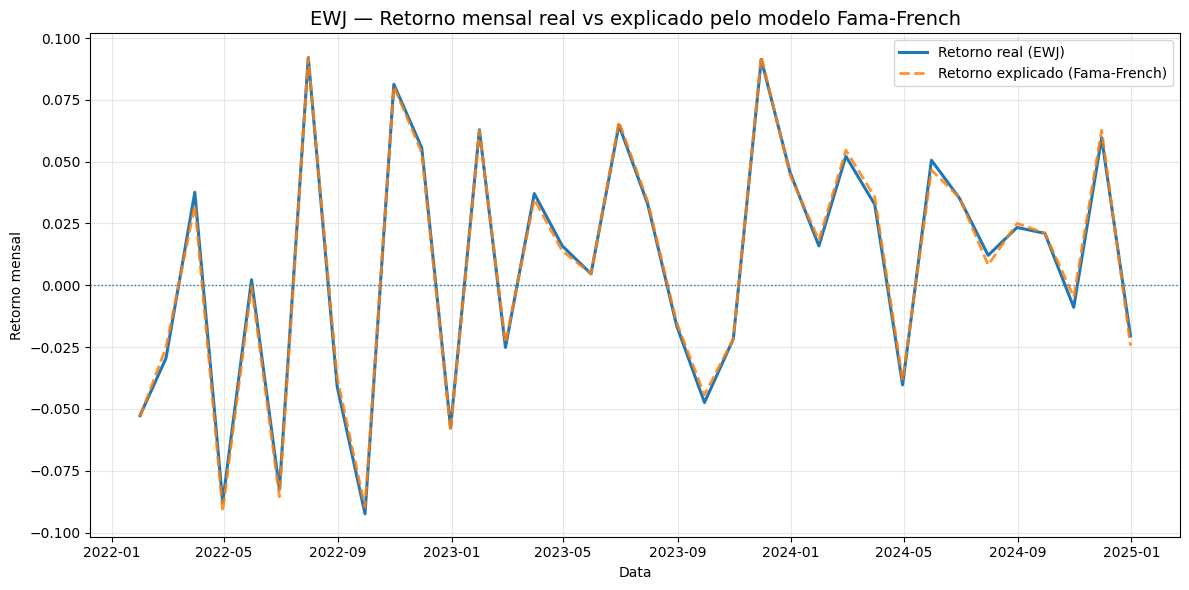

(np.float64(10.683947657578429), np.float64(99.73487200611041), np.float64(0.0007033632491674136))
                                 OLS Regression Results                                
Dep. Variable:          excess_return   R-squared (uncentered):                   0.997
Model:                            OLS   Adj. R-squared (uncentered):              0.997
Method:                 Least Squares   F-statistic:                              4138.
Date:                Tue, 16 Dec 2025   Prob (F-statistic):                    1.44e-42
Time:                        21:25:54   Log-Likelihood:                          164.05
No. Observations:                  36   AIC:                                     -322.1
Df Residuals:                      33   BIC:                                     -317.4
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                 coef

In [38]:
df = french_fama('SPY', 'developed', '2022-01-01', '2024-12-31')
print(df[:3])
print(df[3].summary())